<a href="https://colab.research.google.com/github/birolcabukusta/Tools/blob/main/kibby_conservation_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kibby conservation analysis

Kibby is an "Alignment-free estimation of sequence conservation for
identifying functional sites using protein sequence embeddings"

https://academic.oup.com/bib/article/24/1/bbac599/6984799.
https://github.com/esbgkannan/kibby

Python/Jupyter translation of the original R workflow (Cabukusta) translated by ChatGPT.

This notebook installs/checks dependencies, runs Kibby, expands residue-level conservation scores, plots annotated conservation profiles, and optionally merges with DeepCoil/PCoils data.

> Note: the 15B ESM model is very large (~30 GB checkpoint) and may not run on a typical laptop. The default 650M model is used unless you explicitly change the command.




In [1]:
# Optional: install dependencies inside the notebook
# Uncomment and run once if needed.

!pip install numpy pandas matplotlib openpyxl adjustText torch fair-esm transformers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 3.9 MB/s eta 0:00:00


In [2]:
from pathlib import Path
from datetime import datetime
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from adjustText import adjust_text
    HAS_ADJUST_TEXT = True
except ImportError:
    HAS_ADJUST_TEXT = False
    print("Package 'adjustText' is not installed. Labels will still be drawn, but may overlap.")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300


## 1. Download/check Kibby repository

In [3]:
repo_dir = Path("kibby")

if not repo_dir.exists():
    subprocess.run(["git", "clone", "https://github.com/waylandy/kibby"], check=True)

print(repo_dir.resolve())
import os
os.chdir('kibby/')

/content/kibby


## 2. Show command-line help

In [4]:
subprocess.run([sys.executable, str(repo_dir / "conservation_from_fasta.py"), "-h"], check=False)


CompletedProcess(args=['/usr/bin/python3', 'kibby/conservation_from_fasta.py', '-h'], returncode=0)

## 3. Run Kibby on the query FASTA

In [14]:
# START HERE
# Set paths. You can replace query_sequences.fasta with another FASTA file.

query_name = 'ORP9' #@param {type:"string"}
query_sequence = 'MASIMEGPLSKWTNVMKGWQYRWFVLDYNAGLLSYYTSKDKMMRGSRRGCVRLRGAVIGI DDEDDSTFTITVDQKTFHFQARDADEREKWIHALEETILRHTLQLQGLDSGFVPSVQDFD KKLTEADAYLQILIEQLKLFDDKLQNCKEDEQRKKIETLKETTNSMVESIKHCIVLLQIA KDQSNAEKHADGMISTINPVDAIYQPSPLEPVISTMPSQTVLPPEPVQLCKSEQRPSSLP VGPVLATLGHHQTPTPNSTGSGHSPPSSSLTSPSHVNLSPNTVPEFSYSSSEDEFYDADE FHQSGSSPKRLIDSSGSASVLTHSSSGNSLKRPDTTESLNSSLSNGTSDADLFDSHDDRD DDAEAGSVEEHKSVIMHLLSQVRLGMDLTKVVLPTFILERRSLLEMYADFFAHPDLFVSI SDQKDPKDRMVQVVKWYLSAFHAGRKGSVAKKPYNPILGEIFQCHWTLPNDTEENTELVS EGPVPWVSKNSVTFVAEQVSHHPPISAFYAECFNKKIQFNAHIWTKSKFLGMSIGVHNIG QGCVSCLDYDEHYILTFPNGYGRSILTVPWVELGGECNINCSKTGYSANIIFHTKPFYGG KKHRITAEIFSPNDKKSFCSIEGEWNGVMYAKYATGENTVFVDTKKLPIIKKKVRKLEDQ NEYESRSLWKDVTFNLKIRDIDAATEAKHRLEERQRAEARERKEKEIQWETRLFHEDGEC WVYDEPLLKRLGAAKH' #@param {type:"string"}
query_sequence = "".join(query_sequence.split())
with open("input_fasta.fasta", "w") as f:
    f.write(f">{query_name}\n{query_sequence}\n")
input_fasta = "input_fasta.fasta"

# Unique output filename to prevent overwrite.
output_file_name = f"output_{query_name}.fasta"
output_path = output_file_name

cmd = [
    sys.executable,
    str("conservation_from_fasta.py"),
    str(input_fasta),
    str(output_path),
]

print(cmd)
print("Running:", " ".join(map(str, cmd)))
subprocess.run(cmd, check=True)
print("Wrote:", output_path)


['/usr/bin/python3', 'conservation_from_fasta.py', 'input_fasta.fasta', 'output_ORP9.fasta']
Running: /usr/bin/python3 conservation_from_fasta.py input_fasta.fasta output_ORP9.fasta
Wrote: output_ORP9.fasta


In [ ]:
# Optional: 15B ESM model run. This requires a large checkpoint and much more memory/GPU capacity.
# The checkpoint is commonly cached under ~/.cache/torch/hub/checkpoints/

# cmd_15b = [
#     sys.executable,
#     str(repo_dir / "conservation_from_fasta.py"),
#     str(repo_dir / "query_sequences2.fasta"),
#     str(repo_dir / "query2_LTP_15B.csv"),
#     "-model",
#     "esm2_t48_15B_UR50D",
# ]
# subprocess.run(cmd_15b, check=True)


## 4. Read Kibby output

In [15]:
# Use the most recent run by default.
# To reproduce the R script exactly, replace this with:
# output_path = repo_dir / "output2023_Oct_30_15_54_54.fasta"

output = pd.read_csv(output_path)
output.head()


,header,sequence,conservation
0,ORP9,MASIMEGPLSKWTNVMKGWQYRWFVLDYNAGLLSYYTSKDKMMRGS...,0.4675 0.0991 0.0000 0.0000 0.0964 0.1730 0.69...


## 5. Expand conservation scores into residue-level tables

In [16]:
def expand_conservation(df: pd.DataFrame, include_letters: bool = False) -> pd.DataFrame:
    """Expand Kibby rows into one row per residue.

    Expected columns: header, sequence, conservation.
    conservation is expected to contain space-separated scores.
    """
    rows = []
    for _, row in df.iterrows():
        header = row["header"]
        sequence = str(row["sequence"])
        scores = str(row["conservation"]).split()

        if len(scores) != len(sequence):
            print(f"Warning: {header} has {len(sequence)} residues but {len(scores)} conservation scores.")

        n = min(len(sequence), len(scores))
        for idx in range(n):
            record = {
                "Header": header,
                "Residue": idx + 1,
                "Score": scores[idx],
                "Score2": pd.to_numeric(scores[idx], errors="coerce"),
            }
            if include_letters:
                record["Letter"] = sequence[idx]
            rows.append(record)

    return pd.DataFrame(rows)

output2 = expand_conservation(output, include_letters=False)
output3 = expand_conservation(output, include_letters=True)



,Header,Residue,Score,Score2,Letter
0,ORP9,1,0.4675,0.4675,M
1,ORP9,2,0.0991,0.0991,A
2,ORP9,3,0.0000,0.0000,S
3,ORP9,4,0.0000,0.0000,I
4,ORP9,5,0.0964,0.0964,M


## 6. Plot all conservation profiles

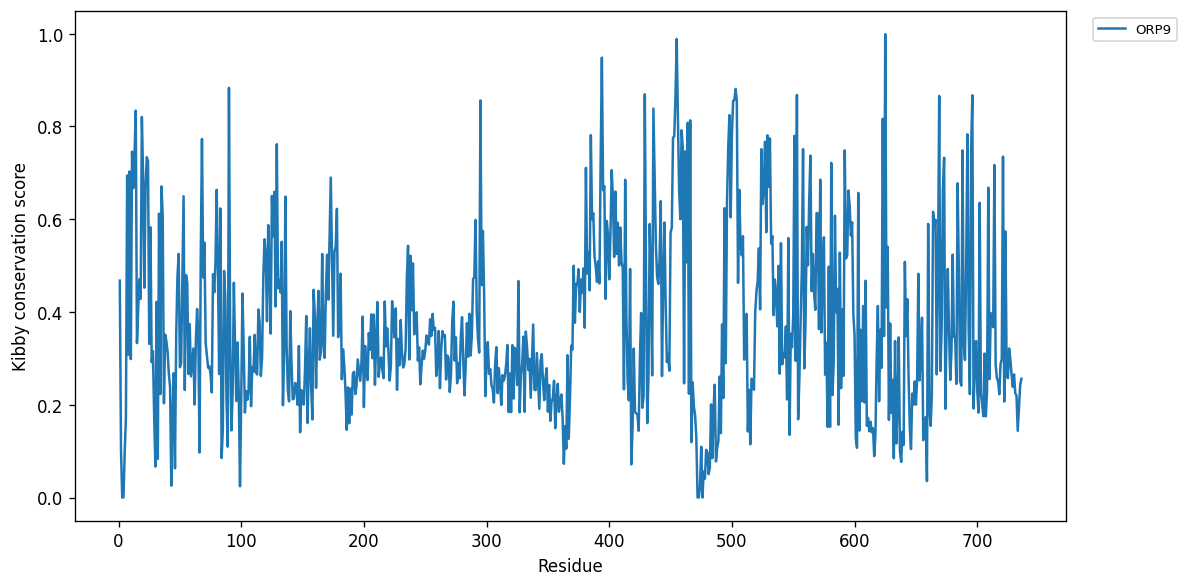

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

for header, group in output2.groupby("Header"):
    ax.plot(group["Residue"], group["Score2"], label=header)

ax.set_xlabel("Residue")
ax.set_ylabel("Kibby conservation score")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()
